# 03 · Segmentação de Clientes em Clusters

Um programa de incentivo não deveria tratar todo mundo do mesmo jeito. Este notebook agrupa os clientes em clusters comportamentais usando K-means, para depois orientar critérios de qualificação e público-alvo de campanha. Essa é a peça central de operacionalizar incentivos que a vaga descreve.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
REPORTS = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

df = pd.read_csv(DATA / "ifood_clean.csv")

## 1. Escolha das variáveis de segmentação

A segmentação usa cinco variáveis que descrevem comportamento e perfil, sem incluir a variável-alvo `Response`. Misturar alvo e variável de segmentação inflaria artificialmente a separação entre clusters, e o resultado deixaria de ser uma segmentação de comportamento para virar uma segmentação da própria resposta.

In [2]:
features = ["Income", "frequencia_total", "ganhos_gerados", "Recency", "Age"]
X = StandardScaler().fit_transform(df[features])
df[features].describe()

,Income,frequencia_total,ganhos_gerados,Recency,Age
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,14.897575,563.789213,48.880752,51.117269
std,20713.046401,7.598261,576.775749,28.950917,11.667616
min,1730.000000,0.000000,4.000000,0.000000,24.000000
25%,35416.000000,8.000000,55.000000,24.000000,43.000000
50%,51412.000000,15.000000,343.000000,49.000000,50.000000
75%,68274.000000,21.000000,964.000000,74.000000,61.000000
max,113734.000000,43.000000,2491.000000,99.000000,80.000000


## 2. Escolha do número de clusters

O método do cotovelo, que olha a inércia por número de clusters, orienta a escolha, sem substituir o julgamento de negócio. O número de clusters também precisa ser operacionalmente administrável por um time de campanhas.

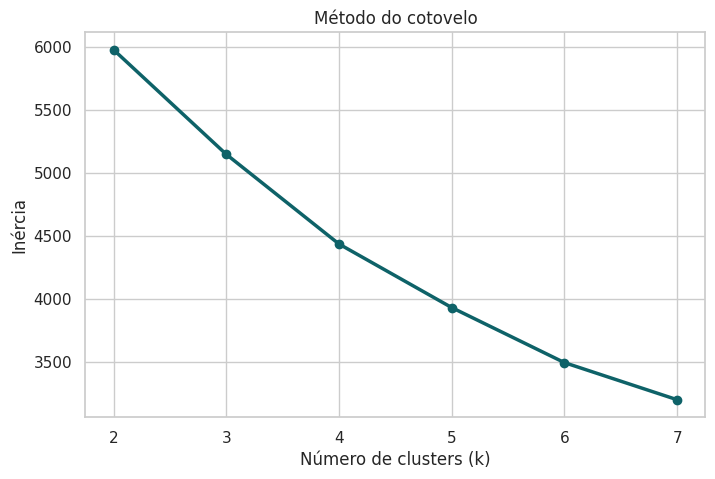

In [3]:
inercias = []
for k in range(2, 8):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inercias.append(modelo.inertia_)

fig, eixo = plt.subplots(figsize=(8, 5))
eixo.plot(range(2, 8), inercias, marker="o", color=TEAL, linewidth=2.5)
eixo.set(xlabel="Número de clusters (k)", ylabel="Inércia", title="Método do cotovelo")
plt.show()

A curva não tem um cotovelo dramático, o que é comum em dados comportamentais reais, sem grupos naturalmente bem separados.

Decisão: usar k=4, o ponto em que o ganho marginal de inércia começa a desacelerar visivelmente, mantendo o número de segmentos administrável para uma equipe de campanhas.

In [4]:
modelo_final = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
df["cluster"] = modelo_final.labels_
df.cluster.value_counts().sort_index()

cluster
0    534
1    452
2    519
3    516
Name: count, dtype: int64

## 3. Perfil de cada cluster

In [5]:
perfil = df.groupby("cluster")[features + ["Response"]].mean().round(1)
perfil["tamanho"] = df.cluster.value_counts().sort_index()
perfil

,Income,frequencia_total,ganhos_gerados,Recency,Age,Response,tamanho
cluster,,,,,,,
0,35017.3,8.7,106.6,24.0,47.4,0.2,534
1,71675.3,21.7,1194.6,50.0,43.5,0.2,452
2,66239.4,21.0,925.6,47.5,63.3,0.2,519
3,36793.1,9.2,120.4,75.0,49.4,0.0,516


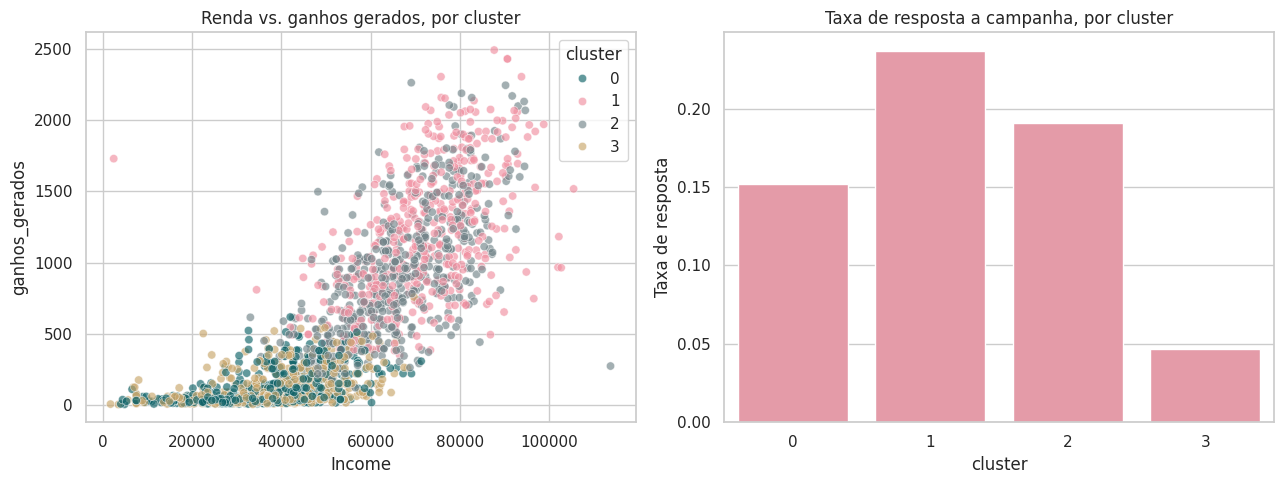

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="Income", y="ganhos_gerados", hue="cluster", palette=[TEAL, CORAL, "#728489", "#C9A66B"], alpha=.65, ax=eixos[0])
eixos[0].set(title="Renda vs. ganhos gerados, por cluster")
sns.barplot(data=df, x="cluster", y="Response", color=CORAL, ax=eixos[1], errorbar=None)
eixos[1].set(title="Taxa de resposta a campanha, por cluster", ylabel="Taxa de resposta")
plt.tight_layout()
plt.show()

## 4. Nomeando os segmentos em linguagem de negócio

| Cluster | Perfil | Nome operacional |
|---|---|---|
| 0 | Renda baixa, frequência baixa, engajamento recente | **Entrada / baixo investimento** |
| 1 | Renda alta, frequência alta, ganhos altos, mais jovens | **Alto valor ativo** |
| 2 | Renda alta, frequência alta, ganhos altos, mais velhos | **Alto valor maduro** |
| 3 | Renda baixa, frequência baixa, recência alta (mais tempo sem comprar) | **Risco de desengajamento** |

O cluster 3 tem taxa de resposta de 4,6%, menos de um terço da média geral de 15,4%. É o segmento que mais precisaria de um incentivo diferente do que já está sendo usado, não de mais do mesmo. Essa é exatamente a informação que orienta um plano de ação colaborativo com os times de campanha.

In [7]:
df.to_csv(DATA / "ifood_clustered.csv", index=False)
print("salvo:", DATA / "ifood_clustered.csv")

salvo: /home/claude/ifood-project/data/ifood_clustered.csv


## Limitação

K-means assume clusters aproximadamente esféricos e é sensível à escala das variáveis, por isso a padronização acontece antes do ajuste. O número de clusters escolhido, k=4, é uma alternativa razoável, não a única defensável. Outra rodada de negócio poderia justificar k=3 ou k=5, dependendo da capacidade operacional de atender segmentos diferentes.

## Conclusão

Existem pelo menos quatro perfis comportamentais estatisticamente distintos entre esses clientes, com taxas de resposta a incentivo bem diferentes entre si. O próximo notebook testa formalmente se essa diferença de resposta é estatisticamente robusta, não só visualmente diferente.